In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os
warnings.filterwarnings('ignore')

def safe_read_csv(filename):
    if os.path.exists(filename):
        return pd.read_csv(filename)
    else:
        raise FileNotFoundError(f"File not found: {filename}. Check path or filename.")
        
nav = safe_read_csv('nav_history.csv')
nav['date'] = pd.to_datetime(nav['date'], errors='coerce')
nav['nav']  = pd.to_numeric(nav['nav'], errors='coerce')
nav = nav.dropna().sort_values(['amfi_code','date'])

sp  = safe_read_csv('scheme_performance.csv')
txn = safe_read_csv('investor_transactions.csv')
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'], errors='coerce')

ph  = safe_read_csv('portfolio_holdings.csv')
ph['weight_pct'] = pd.to_numeric(ph['weight_pct'], errors='coerce')


returns = nav.copy()
returns['daily_return'] = returns.groupby('amfi_code')['nav'].pct_change()
returns = returns.dropna()

print(f" Funds       : {nav['amfi_code'].nunique()}")
print(f" NAV records : {len(nav):,}")
print(f" Transactions: {len(txn):,}")
print(f"Date range  : {nav['date'].min().date()} → {nav['date'].max().date()}")


 Funds       : 40
 NAV records : 46,000
 Transactions: 32,778
Date range  : 2022-01-03 → 2026-05-29


In [13]:
var_results = []
for code, grp in returns.groupby('amfi_code'):
    r = grp['daily_return'].dropna()
    if len(r) < 50: continue
    var_95  = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()
    var_results.append({
        'amfi_code'         : code,
        'VaR_95_pct'        : round(var_95  * 100, 4),
        'CVaR_95_pct'       : round(cvar_95 * 100, 4),
        'total_trading_days': len(r)
    })

var_df = pd.DataFrame(var_results).merge(
    sp[['amfi_code','scheme_name','category','risk_grade','sharpe_ratio']],
    on='amfi_code', how='left').sort_values('VaR_95_pct')
var_df.to_csv('var_cvar_report.csv', index=False)

print(" Highest Risk (Worst VaR):")
print(var_df[['scheme_name','VaR_95_pct','CVaR_95_pct','risk_grade']].head(5).to_string(index=False))
print("\n Lowest Risk (Best VaR):")
print(var_df[['scheme_name','VaR_95_pct','CVaR_95_pct','risk_grade']].tail(5).to_string(index=False))


 Highest Risk (Worst VaR):
                                    scheme_name  VaR_95_pct  CVaR_95_pct risk_grade
      SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384  Very High
         Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667  Very High
         ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459  Very High
 Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304  Very High
     SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595  Very High

 Lowest Risk (Best VaR):
                                          scheme_name  VaR_95_pct  CVaR_95_pct risk_grade
 Nippon India Gilt Securities Fund - Regular - Growth     -0.3804      -0.4919        Low
         HDFC Short Term Debt Fund - Regular - Growth     -0.3793      -0.4994        Low
                 Kotak Liquid Fund - Regular - Growth     -0.0285      -0.0411        Low
                  ABSL Liquid Fund - Regular - Growth     -0.0269      -0.0422     

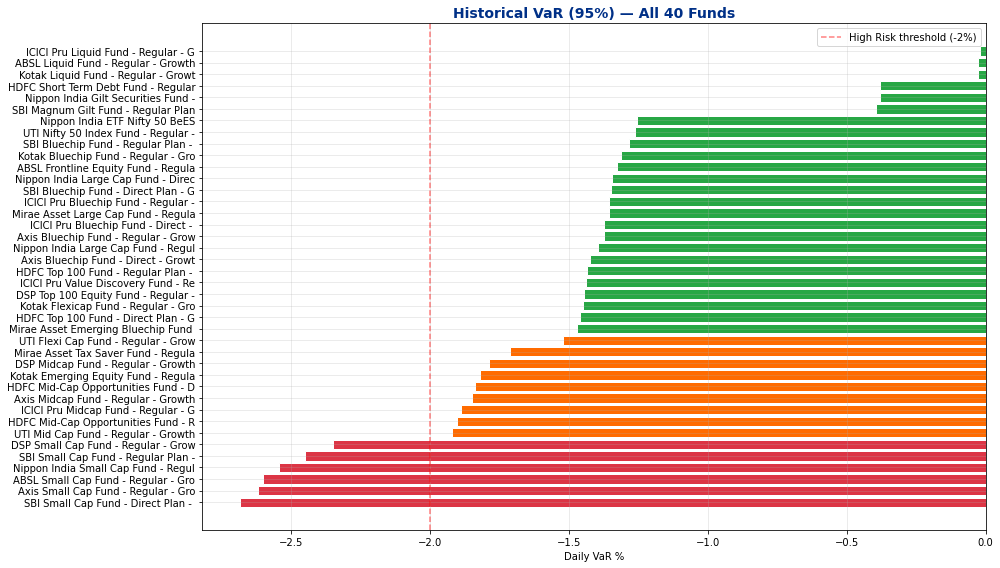

✅ var_cvar_report.csv saved!


In [14]:
fig, ax = plt.subplots(figsize=(14, 8))
colors = var_df['VaR_95_pct'].apply(
    lambda x: '#dc3545' if x < -2 else ('#FF6B00' if x < -1.5 else '#28a745'))
ax.barh(var_df['scheme_name'].str[:35], var_df['VaR_95_pct'], color=colors, edgecolor='white')
ax.axvline(x=-2.0, color='red', linestyle='--', alpha=0.5, label='High Risk threshold (-2%)')
ax.set_title('Historical VaR (95%) — All 40 Funds', fontsize=14, fontweight='bold', color='#003087')
ax.set_xlabel('Daily VaR %')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("var_cvar_report.csv saved!")

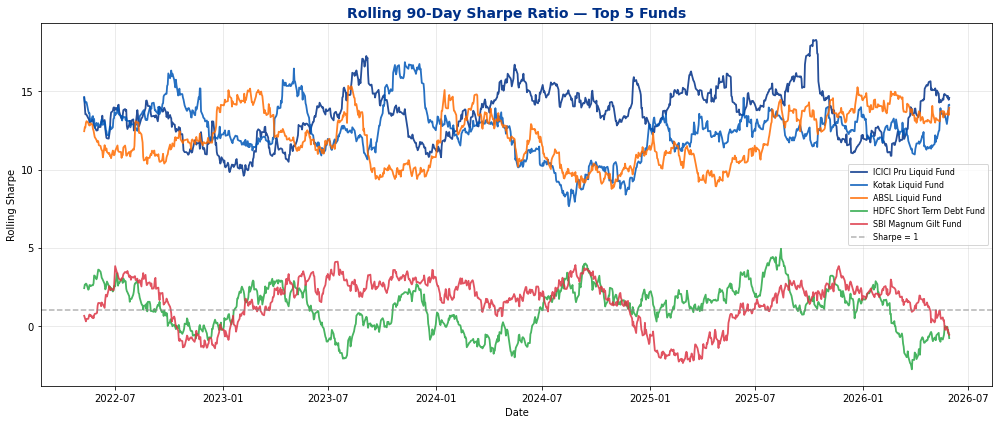

✅ rolling_sharpe_chart.png saved!


In [15]:
top5_codes = sp.nlargest(5, 'sharpe_ratio')['amfi_code'].tolist()
top5_names = sp.set_index('amfi_code')['scheme_name'].to_dict()
colors = ['#003087','#0057B8','#FF6B00','#28a745','#dc3545']

fig, ax = plt.subplots(figsize=(14, 6))
for i, code in enumerate(top5_codes):
    grp = returns[returns['amfi_code']==code].set_index('date')['daily_return']
    rs  = (grp.rolling(90).mean() / grp.rolling(90).std()) * np.sqrt(252)
    name = top5_names.get(code,'').split(' - ')[0][:28]
    ax.plot(rs.index, rs.values, label=name, color=colors[i], linewidth=1.8, alpha=0.85)

ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.6, label='Sharpe = 1')
ax.set_title('Rolling 90-Day Sharpe Ratio — Top 5 Funds', fontsize=14, fontweight='bold', color='#003087')
ax.set_xlabel('Date'); ax.set_ylabel('Rolling Sharpe')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(" rolling_sharpe_chart.png saved!")


In [16]:
txn['year'] = txn['transaction_date'].dt.year
first_year  = txn.groupby('investor_id')['year'].min().rename('cohort_year')
txn2 = txn.merge(first_year, on='investor_id')
sip_txn = txn2[txn2['transaction_type']=='SIP']

cohort = sip_txn.groupby('cohort_year').agg(
    investor_count = ('investor_id','nunique'),
    avg_sip_amount = ('amount_inr','mean'),
    total_invested = ('amount_inr','sum')
).round(2).reset_index()

top_fund = (txn2.groupby(['cohort_year','amfi_code'])['amount_inr'].sum()
              .reset_index().sort_values('amount_inr', ascending=False)
              .groupby('cohort_year').first().reset_index()
              .merge(sp[['amfi_code','scheme_name']], on='amfi_code', how='left'))
cohort = cohort.merge(top_fund[['cohort_year','scheme_name']], on='cohort_year', how='left')
cohort.rename(columns={'scheme_name':'top_fund'}, inplace=True)
cohort.to_csv('cohort_analysis.csv', index=False)

print("📊 Cohort Analysis:")
print(cohort.to_string(index=False))


📊 Cohort Analysis:
 cohort_year  investor_count  avg_sip_amount  total_invested                                    top_fund
        2024            4624        10996.89       214978121  UTI Nifty 50 Index Fund - Regular - Growth
        2025             138        13505.21         2255370   SBI Small Cap Fund - Direct Plan - Growth


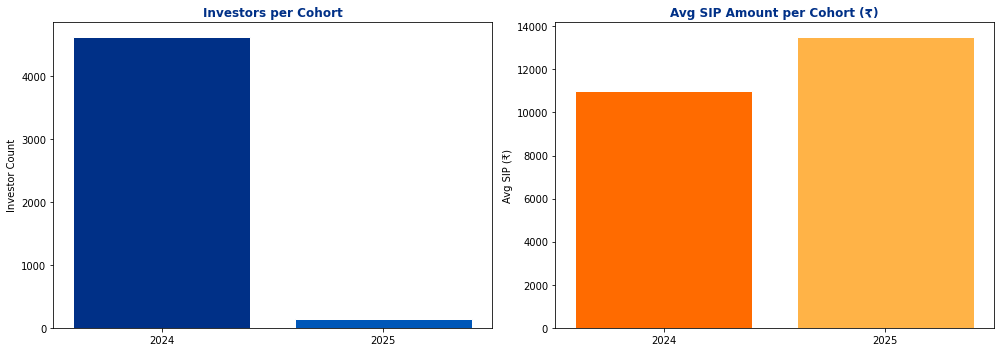

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(cohort['cohort_year'].astype(str), cohort['investor_count'],
            color=['#003087','#0057B8'], edgecolor='white')
axes[0].set_title('Investors per Cohort', fontweight='bold', color='#003087')
axes[0].set_ylabel('Investor Count')

axes[1].bar(cohort['cohort_year'].astype(str), cohort['avg_sip_amount'],
            color=['#FF6B00','#FFB347'], edgecolor='white')
axes[1].set_title('Avg SIP Amount per Cohort (₹)', fontweight='bold', color='#003087')
axes[1].set_ylabel('Avg SIP (₹)')
plt.tight_layout(); plt.show()


In [19]:
sip_only  = txn[txn['transaction_type']=='SIP'].sort_values(['investor_id','transaction_date'])
sip_gaps  = sip_only.groupby('investor_id').apply(
    lambda x: x['transaction_date'].diff().dt.days.mean() if len(x) >= 6 else None
).dropna().reset_index()
sip_gaps.columns = ['investor_id','avg_gap_days']
sip_gaps['avg_gap_days'] = sip_gaps['avg_gap_days'].round(1)
sip_gaps['status'] = sip_gaps['avg_gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Regular')
sip_gaps.to_csv('sip_continuity.csv', index=False)

at_risk = sip_gaps[sip_gaps['status']=='At-Risk']
regular = sip_gaps[sip_gaps['status']=='Regular']
print(f"Total eligible (6+ SIPs) : {len(sip_gaps):,}")
print(f"At-Risk (gap > 35d)   : {len(at_risk):,}")
print(f" Regular               : {len(regular):,}")
print(f"Continuity Rate       : {round(len(regular)/len(sip_gaps)*100,1)}%")


Total eligible (6+ SIPs) : 1,362
At-Risk (gap > 35d)   : 1,332
 Regular               : 30
Continuity Rate       : 2.2%


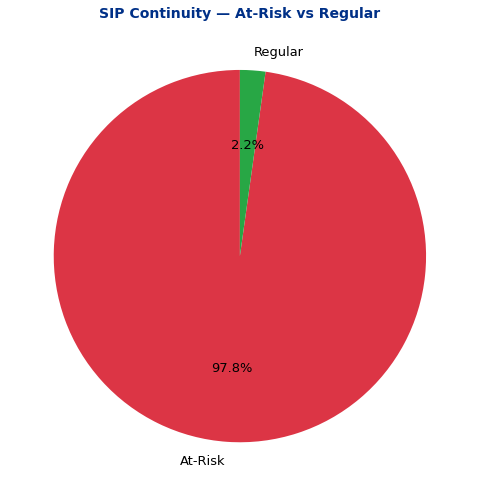

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))
counts = sip_gaps['status'].value_counts()
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
       colors=['#dc3545','#28a745'], startangle=90, textprops={'fontsize':13})
ax.set_title('SIP Continuity — At-Risk vs Regular', fontsize=14, fontweight='bold', color='#003087')
plt.tight_layout(); plt.show()


In [21]:
def recommend_funds(risk_appetite):
    filtered = sp[sp['risk_grade'] == risk_appetite]
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name','category','sharpe_ratio','return_3yr_pct','std_dev_ann_pct','risk_grade']
    ].reset_index(drop=True)
    top3.index += 1
    return top3

for risk in ['Low', 'Moderate', 'High']:
    print(f"\n{'='*65}")
    print(f"  🎯 Top 3 Funds — {risk} Risk Appetite")
    print('='*65)
    print(recommend_funds(risk).to_string())



  🎯 Top 3 Funds — Low Risk Appetite
                                scheme_name category  sharpe_ratio  return_3yr_pct  std_dev_ann_pct risk_grade
1  ICICI Pru Liquid Fund - Regular - Growth   Liquid          7.68            7.68              0.5        Low
2      Kotak Liquid Fund - Regular - Growth   Liquid          6.18            6.18              0.5        Low
3       ABSL Liquid Fund - Regular - Growth   Liquid          5.14            5.14              0.5        Low

  🎯 Top 3 Funds — Moderate Risk Appetite
                                     scheme_name   category  sharpe_ratio  return_3yr_pct  std_dev_ann_pct risk_grade
1      HDFC Top 100 Fund - Regular Plan - Growth  Large Cap          1.06           14.84             14.0   Moderate
2  Mirae Asset Large Cap Fund - Regular - Growth  Large Cap          1.06           14.81             14.0   Moderate
3      ICICI Pru Bluechip Fund - Direct - Growth  Large Cap          1.03           14.41             14.0   Moderate

  🎯 

In [22]:
hhi = ph.groupby('amfi_code').apply(
    lambda x: (x['weight_pct']**2).sum()).reset_index()
hhi.columns = ['amfi_code','HHI']
hhi = hhi.merge(sp[['amfi_code','scheme_name','category']], on='amfi_code', how='left')
hhi['HHI'] = hhi['HHI'].round(2)
hhi['concentration'] = hhi['HHI'].apply(
    lambda x: 'High' if x>1500 else ('Moderate' if x>800 else 'Low'))
hhi = hhi.sort_values('HHI', ascending=False)
hhi.to_csv('sector_hhi.csv', index=False)
print(hhi[['scheme_name','HHI','concentration']].to_string(index=False))


                                           scheme_name      HHI concentration
                 Axis Bluechip Fund - Regular - Growth  2064.48          High
                ABSL Small Cap Fund - Regular - Growth  2007.00          High
             SBI Small Cap Fund - Direct Plan - Growth  1747.51          High
            UTI Nifty 50 Index Fund - Regular - Growth  1747.09          High
        Nippon India Large Cap Fund - Regular - Growth  1682.98          High
 Mirae Asset Emerging Bluechip Fund - Regular - Growth  1679.30          High
              ICICI Pru Midcap Fund - Regular - Growth  1575.70          High
     ICICI Pru Value Discovery Fund - Regular - Growth  1537.94          High
     HDFC Mid-Cap Opportunities Fund - Direct - Growth  1524.14          High
                Kotak Bluechip Fund - Regular - Growth  1496.80      Moderate
         Mirae Asset Tax Saver Fund - Regular - Growth  1493.96      Moderate
    HDFC Mid-Cap Opportunities Fund - Regular - Growth  1475.92 

NameError: name 'patches' is not defined

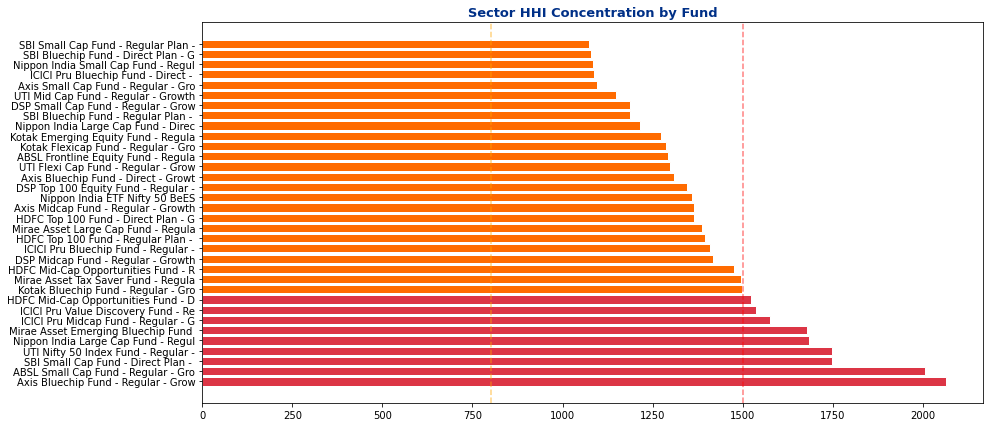

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))
cmap = {'High':'#dc3545','Moderate':'#FF6B00','Low':'#28a745'}
ax.barh(hhi['scheme_name'].str[:35], hhi['HHI'],
        color=hhi['concentration'].map(cmap), edgecolor='white')
ax.axvline(x=1500, color='red',    linestyle='--', alpha=0.5, label='High (1500)')
ax.axvline(x=800,  color='orange', linestyle='--', alpha=0.5, label='Moderate (800)')
ax.set_title('Sector HHI Concentration by Fund', fontsize=13, fontweight='bold', color='#003087')
patches = [patches.Patch(color=v, label=k) for k,v in cmap.items()]
ax.legend(handles=patches); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
